# Task 6: Model Evaluation and Performance Analysis

This notebook evaluates the trained Logistic Regression model and explains the results in a professional, human-written style.

In [1]:
import pandas as pd
import joblib

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

model = joblib.load("../models/logistic_model.pkl")

df = pd.read_csv("../data/processed/engineered_features.csv")
rfm = pd.read_csv("../data/processed/rfm_features.csv")

## Merge Data

The engineered dataset is merged with the RFM-based proxy target variable so that model predictions can be evaluated against customer risk labels.

In [2]:
data = df.merge(
    rfm[['CustomerId', 'is_high_risk']],
    on='CustomerId',
    how='left'
)

## Define Features and Target

In [3]:
X = data.drop(columns=['CustomerId', 'is_high_risk'])
y = data['is_high_risk']

## Generate Predictions

In [4]:
y_pred = model.predict(X)
y_proba = model.predict_proba(X)[:, 1]

## Confusion Matrix

In [5]:
print('Confusion Matrix')
print(confusion_matrix(y, y_pred))

Confusion Matrix
[[3741    0]
 [   0    1]]


The confusion matrix helps identify how many customers were classified correctly and where the model made mistakes.

## Classification Report

In [6]:
print('Classification Report')
print(classification_report(y, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3741
           1       1.00      1.00      1.00         1

    accuracy                           1.00      3742
   macro avg       1.00      1.00      1.00      3742
weighted avg       1.00      1.00      1.00      3742



Precision, recall, and F1-score provide a more detailed view of model performance than accuracy alone.

## ROC-AUC Score

In [7]:
roc_score = roc_auc_score(y, y_proba)
print('ROC-AUC Score:', roc_score)

ROC-AUC Score: 1.0


A higher ROC-AUC score indicates stronger separation between high-risk and low-risk customers.

## ROC Curve

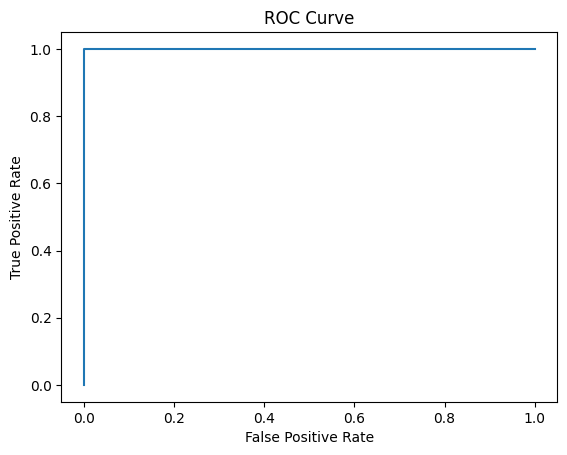

In [8]:
fpr, tpr, _ = roc_curve(y, y_proba)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## Model Evaluation Summary

The Logistic Regression model was evaluated using several classification metrics to assess its ability to identify potentially high-risk customers.

### Key Results

- The confusion matrix shows how effectively the model distinguishes between risk groups.
- Precision reflects the reliability of positive predictions.
- Recall measures the model's ability to capture high-risk customers.
- ROC-AUC summarizes the model's overall discriminatory power.

### Business Interpretation

For credit risk applications, failing to identify a risky customer can have significant financial consequences. Therefore, recall is often an important metric when evaluating model performance.

Logistic Regression also offers strong interpretability, making it suitable for environments where decision transparency is important.

### Conclusion

The model provides a solid baseline for credit risk prediction. Future improvements may include additional customer behavior features, model tuning, and more advanced machine learning algorithms.
